In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#imports
import sys
import os
from os import listdir
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import PIL
import random
random.seed(100)
np.random.seed(100)

# Visualização de Dados e Imagens Médicas
import matplotlib.image as mpimg

import tensorflow as tf

import cv2

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model


from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

from tensorflow.keras.layers import Input, Dense, Dropout

import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import warnings

warnings.filterwarnings("ignore")

#**Gestão de Diretórios e Caminhos de Dados**

In [ ]:
#Obtém o caminho absoluto do diretório onde o notebook está sendo executado
current_working_directory = os.getcwd()

#Exibe o caminho no console para verificação
print(current_working_directory)

/content


In [ ]:
#Aquisição e carregamento para metadados
#Definição do caminho absoluto para o arquivo de metadados (CSV)
csv_path = '/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/meta.csv'

#Carregamento do arquivo CSV utilizando a biblioteca Pandas
df_meta = pd.read_csv(csv_path)

#Visualização das primeiras linhas
df_meta

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
...,...,...,...,...,...,...,...,...,...
6770,1.3.6.1.4.1.9590.100.1.2.424889390711092892018...,1.3.6.1.4.1.9590.100.1.2.416082235212771925836...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
6771,1.3.6.1.4.1.9590.100.1.2.627433012114953458354...,1.3.6.1.4.1.9590.100.1.2.763083562112003848332...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,1
6772,1.3.6.1.4.1.9590.100.1.2.250048723412722873040...,1.3.6.1.4.1.9590.100.1.2.354475681612412200004...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,1
6773,1.3.6.1.4.1.9590.100.1.2.323173986211744534717...,1.3.6.1.4.1.9590.100.1.2.185043095411645186738...,MG,cropped images,BREAST,1,CBIS-DDSM,1,1


In [ ]:
#O arquivo 'dicom_info.csv' funciona como a ponte entre os dados clínicos e a localização física dos arquivos no armazenamento
dicom_data = pd.read_csv('/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/dicom_info.csv')

#Exibição do cabeçalho para validar colunas críticas
dicom_data.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [ ]:
#Análise exploratória de dados
#O método .info() fornece um resumo estrutural do dataframe
dicom_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   file_path                                    10237 non-null  object 
 1   image_path                                   10237 non-null  object 
 2   AccessionNumber                              0 non-null      float64
 3   BitsAllocated                                10237 non-null  int64  
 4   BitsStored                                   10237 non-null  int64  
 5   BodyPartExamined                             10237 non-null  object 
 6   Columns                                      10237 non-null  int64  
 7   ContentDate                                  10237 non-null  int64  
 8   ContentTime                                  10237 non-null  float64
 9   ConversionType                               10237 non-null  object 
 10

In [ ]:
#Identificação dos tipos de imagens
#O método .unique() lista todos os valores distintos na coluna 'SeriesDescription'
dicom_data.SeriesDescription.unique()

array(['cropped images', 'full mammogram images', nan, 'ROI mask images'],
      dtype=object)

In [ ]:
#Mapeamento de tratamento de caminhos de arquivos
#Define a raiz de onde as imagens JPEG estão armazenadas no meu Google Drive
image_dir = '/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg'

#Separa os caminhos das imagens em três categorias distintas baseadas na descrição técnica:
#1. Imagens completas da mama.
#2. Imagens recortadas (focadas na lesão).
#3. Máscaras de Segmentação (ROI)
full_mammogram_images = dicom_data[dicom_data.SeriesDescription == 'full mammogram images'].image_path
cropped_images = dicom_data[dicom_data.SeriesDescription == 'cropped images'].image_path
roi_mask_images = dicom_data[dicom_data.SeriesDescription == 'ROI mask images'].image_path

# Ajusta os caminhos originais do CSV para apontar para a pasta no Drive.
full_mammogram_images = full_mammogram_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
cropped_images = cropped_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
roi_mask_images = roi_mask_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))

#Exibe o primeiro caminho da lista para verificar se a substituição ocorreu corretamente
full_mammogram_images.iloc[0]

'/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg'

In [ ]:
#O atributo .shape retorna o número de caminhos de arquivos
full_mammogram_images.shape

(2857,)

In [ ]:
#O método .iloc[0] acessa o primeiro elemento da série 'cropped_images'
cropped_images.iloc[0]

'/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg'

In [ ]:
#O atributo .shape retorna o número total de amostras de imagens recortadas (cropped)
cropped_images.shape

(3567,)

In [ ]:
#O método .iloc[0] acessa o primeiro caminho da lista 'roi_mask_images'
roi_mask_images.iloc[0]

'/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg'

In [ ]:
#O atributo .shape retorna o total de arquivos de máscaras (ROI) encontrados
roi_mask_images.shape

(3247,)

In [ ]:
# Inicializa dicionários para busca rápida de caminhos
full_mammogram_dict = dict()
cropped_dict = dict()
roi_mask_dict = dict()

#Itera sobre os caminhos das imagens completas
for dicom in full_mammogram_images:
    # print(dicom)
    key = dicom.split("/")[7]
    # print(key)
    full_mammogram_dict[key] = dicom

#Itera sobre os recortes (crops) e mapeia para o dicionário correspondente
for dicom in cropped_images:
    key = dicom.split("/")[7]
    cropped_dict[key] = dicom

# Itera sobre as máscaras (ROI) e mapeia para o dicionário correspondente
for dicom in roi_mask_images:
    key = dicom.split("/")[7]
    roi_mask_dict[key] = dicom

In [ ]:
#Validação do primeiro mapeamento de dicionario
next(iter((full_mammogram_dict.items())))

('1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849',
 '/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg')

In [ ]:
#Monitoramento de memoria RAM
#O método sys.getsizeof() retorna o tamanho do objeto (dicionário) em byteS
sys.getsizeof(full_mammogram_dict)

103856

In [ ]:
#Extrai o primeiro par (chave: valor) do dicionário de imagens recortadas
next(iter((cropped_dict.items())))

('1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304',
 '/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg')

In [ ]:
#Analise de consumo de memoria
#O método sys.getsizeof() retorna o tamanho do objeto 'cropped_images' em bytes
sys.getsizeof(cropped_images)

651905

In [ ]:
#Validação do mapeamento de mascaras
#Extrai o primeiro par (chave: valor) do dicionário de máscaras de segmentação
next(iter((roi_mask_dict.items())))

('1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138',
 '/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg')

In [ ]:
#Analise de consumo de memoria
#O método sys.getsizeof() retorna o tamanho em bytes da Série 'roi_mask_images'
sys.getsizeof(roi_mask_images)

593425

In [ ]:
#Carregamento das descrições clinicas e rotulos

#Carrega os dados de treinamento e teste para casos de MASSAS
mass_train_data = pd.read_csv('/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/mass_case_description_train_set.csv')
mass_test_data = pd.read_csv('/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/mass_case_description_test_set.csv')

#Carrega os dados de treinamento e teste para casos de CALCIFICAÇÕES
calc_train_data = pd.read_csv('/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/calc_case_description_train_set.csv')
calc_test_data = pd.read_csv('/content/drive/MyDrive/TCC_Cancer_Mama/dataset/csv/calc_case_description_test_set.csv')

In [ ]:
#O método .head() exibe as 5 primeiras linhas do conjunto
mass_train_data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [ ]:
mass_test_data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [ ]:
calc_train_data.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [ ]:
calc_test_data.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....
3,P_00038,2,RIGHT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....
4,P_00038,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_MLO/1.3.6.1.4.1.9590.1...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...


In [ ]:
#Distribuição de patologias

#Conta a frequência de cada categoria no conjunto de TREINO de massas
train_counts = mass_train_data['pathology'].value_counts()

#Conta a frequência de cada categoria no conjunto de TESTE de massas
test_counts = mass_test_data['pathology'].value_counts()

#Exibição dos resultados
print("Distribuição no Conjunto de Treino (Massas):")
print(train_counts)

print("\nDistribuição no Conjunto de Teste (Massas):")
print(test_counts)

Distribuição no Conjunto de Treino (Massas):
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64

Distribuição no Conjunto de Teste (Massas):
pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64


In [ ]:
#Realiza a contagem de frequência das categorias patológicas para os casos de CALCIFICAÇÕES no treino
train_counts = calc_train_data['pathology'].value_counts()

# Realiza a contagem para o conjunto de teste de calcificações
test_counts = calc_test_data['pathology'].value_counts()

# Exibição dos resultados
print("Distribuição no Conjunto de Treino (Calcificações):")
print(train_counts)

print("\nDistribuição no Conjunto de Teste (Calcificações):")
print(test_counts)

Distribuição no Conjunto de Treino (Calcificações):
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

Distribuição no Conjunto de Teste (Calcificações):
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64


In [ ]:
#Função de correção e vinculação de caminhos (MASSAS)

def fix_image_path_mass(dataset):
    """
    Esta função percorre o DataFrame e substitui os caminhos de arquivos originais (inválidos)
    pelos caminhos absolutos corretos armazenados no Google Drive
    """
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammogram_dict:
            dataset.iloc[i, 11] = full_mammogram_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_dict:
            dataset.iloc[i, 12] = cropped_dict[img_name]

        img_name = img[13].split("/")[2]
        if img_name in roi_mask_dict:
            dataset.iloc[i, 13] = roi_mask_dict[img_name]

In [ ]:
img_name = mass_train_data.iloc[0, 11].split("/")[1]

print("Extraído:", img_name)
print("Existe no dict?", img_name in full_mammogram_dict)

Extraído: 1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994
Existe no dict? False


In [ ]:
print("Extraído:", list(full_mammogram_dict.values())[0])

print("Extraído:",list(full_mammogram_dict.keys())[0])

Extraído: /content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
Extraído: 1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849


In [ ]:
#Chama a função fix_image_path_mass passando o DataFrame de treinamento
#Este comando percorre todas as linhas do 'mass_train_data' e:
#1. Localiza o ID da imagem na coluna de caminhos original
#2. Busca o endereço físico correspondente no seu Google Drive (via dicionários)
#3. Sobrescreve o DataFrame com o caminho absoluto final
fix_image_path_mass(mass_train_data)

In [ ]:
fix_image_path_mass(mass_test_data)

In [ ]:
mass_train_data

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,P_02033,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,3,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1314,P_02079,2,RIGHT,CC,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1315,P_02079,2,RIGHT,MLO,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
mass_test_data

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,P_01825,2,RIGHT,MLO,1,mass,LOBULATED,MICROLOBULATED,3,BENIGN_WITHOUT_CALLBACK,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
374,P_01833,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,5,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
375,P_01865,2,LEFT,MLO,1,mass,IRREGULAR,ILL_DEFINED,4,MALIGNANT,2,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
376,P_01912,3,RIGHT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
#Mesma coisa que a função fix_image_path_mass só que com as calcificações
def fix_image_path_calc(dataset):
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammogram_dict:
            dataset.iloc[i, 11] = full_mammogram_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_dict:
            dataset.iloc[i, 12] = cropped_dict[img_name]

        img_name = img[13].split("/")[2]
        if img_name in roi_mask_dict:
            dataset.iloc[i, 13] = roi_mask_dict[img_name]

In [ ]:
fix_image_path_calc(calc_train_data)

In [ ]:
fix_image_path_calc(calc_test_data)

In [ ]:
calc_train_data

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1541,P_02566,2,RIGHT,MLO,1,calcification,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,5,MALIGNANT,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1542,P_02572,2,LEFT,CC,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1543,P_02572,2,LEFT,MLO,1,calcification,AMORPHOUS,CLUSTERED,0,MALIGNANT,2,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1544,P_02584,1,LEFT,CC,1,calcification,PLEOMORPHIC,SEGMENTAL,0,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
calc_test_data

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....
3,P_00038,2,RIGHT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....
4,P_00038,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_MLO/1.3.6.1.4.1.9590.1...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,P_02464,2,RIGHT,MLO,1,calcification,FINE_LINEAR_BRANCHING,CLUSTERED,0,MALIGNANT,4,Calc-Test_P_02464_RIGHT_MLO/1.3.6.1.4.1.9590.1...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_02464_RIGHT_MLO_1/1.3.6.1.4.1.9590...
322,P_02498,4,RIGHT,CC,1,calcification,PUNCTATE,CLUSTERED,0,BENIGN,3,Calc-Test_P_02498_RIGHT_CC/1.3.6.1.4.1.9590.10...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_02498_RIGHT_CC_1/1.3.6.1.4.1.9590....
323,P_02498,4,RIGHT,MLO,1,calcification,PUNCTATE,CLUSTERED,0,BENIGN,3,Calc-Test_P_02498_RIGHT_MLO/1.3.6.1.4.1.9590.1...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_02498_RIGHT_MLO_1/1.3.6.1.4.1.9590...
324,P_02501,3,RIGHT,CC,1,calcification,PLEOMORPHIC,CLUSTERED,0,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,Calc-Test_P_02501_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [ ]:
#O método .unique() extrai todos os valores distintos presentes na coluna 'pathology'
mass_train_data.pathology.unique()

array(['MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'], dtype=object)

In [ ]:
calc_train_data.pathology.unique()

array(['MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'], dtype=object)

In [ ]:
mass_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
dtypes: int64(4), object(10)
memory usage: 14

In [ ]:
calc_train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1546 non-null   object
 1   breast density           1546 non-null   int64 
 2   left or right breast     1546 non-null   object
 3   image view               1546 non-null   object
 4   abnormality id           1546 non-null   int64 
 5   abnormality type         1546 non-null   object
 6   calc type                1526 non-null   object
 7   calc distribution        1170 non-null   object
 8   assessment               1546 non-null   int64 
 9   pathology                1546 non-null   object
 10  subtlety                 1546 non-null   int64 
 11  image file path          1546 non-null   object
 12  cropped image file path  1546 non-null   object
 13  ROI mask file path       1546 non-null   object
dtypes: int64(4), object(10)
memory usage: 16

In [ ]:
#Normalização e Renomeio das colunas

#O método .rename() substitui nomes com espaços por nomes com 'underscores' (_)
mass_train = mass_train_data.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'mass shape': 'mass_shape',
                                           'mass margins': 'mass_margins',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

mass_train.head()

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,mass_shape,mass_margins,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
calc_train = calc_train_data.rename(columns={'left or right breast': 'left_or_right_breast',
                                             'breast density':'breast_density',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'calc type': 'calc_type',
                                           'calc distribution': 'calc_distribution',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

calc_train.head()

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc_type,calc_distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
#O método .isnull().sum() percorre todas as colunas do DataFrame 'mass_train' e:
#1. Identifica células vazias ou nulas (NaN)
#2. Soma a quantidade de nulos por coluna
mass_train.isnull().sum()

,0
patient_id,0
breast_density,0
left_or_right_breast,0
image_view,0
abnormality_id,0
abnormality_type,0
mass_shape,4
mass_margins,43
assessment,0
pathology,0


In [ ]:
calc_train.isnull().sum()

,0
patient_id,0
breast_density,0
left_or_right_breast,0
image_view,0
abnormality_id,0
abnormality_type,0
calc_type,20
calc_distribution,376
assessment,0
pathology,0


In [ ]:
#Tratamento de dados Faltantes
#O método 'bfill' (backward fill) preenche os valores nulos (NaN) com o próximo valor
mass_train['mass_shape'] = mass_train['mass_shape'].fillna(method='bfill')
mass_train['mass_margins'] = mass_train['mass_margins'].fillna(method='bfill')

#Verifica novamente a soma de valores nulos
mass_train.isnull().sum()

,0
patient_id,0
breast_density,0
left_or_right_breast,0
image_view,0
abnormality_id,0
abnormality_type,0
mass_shape,0
mass_margins,0
assessment,0
pathology,0


In [ ]:
calc_train['calc_type'] = calc_train['calc_type'].fillna(method='bfill')
calc_train['calc_distribution'] = calc_train['calc_distribution'].fillna(method='bfill')

calc_train.isnull().sum()

,0
patient_id,0
breast_density,0
left_or_right_breast,0
image_view,0
abnormality_id,0
abnormality_type,0
calc_type,0
calc_distribution,0
assessment,0
pathology,0


In [ ]:
mass_test_data.isnull().sum()

,0
patient_id,0
breast_density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
mass shape,0
mass margins,17
assessment,0
pathology,0


In [ ]:
calc_test_data.isnull().sum()

,0
patient_id,0
breast density,0
left or right breast,0
image view,0
abnormality id,0
abnormality type,0
calc type,4
calc distribution,63
assessment,0
pathology,0


In [ ]:
print(mass_test_data.columns,'\n')

mass_test = mass_test_data.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'mass shape': 'mass_shape',
                                           'mass margins': 'mass_margins',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

mass_test.columns

Index(['patient_id', 'breast_density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'mass shape', 'mass margins',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object') 



Index(['patient_id', 'breast_density', 'left_or_right_breast', 'image_view',
       'abnormality_id', 'abnormality_type', 'mass_shape', 'mass_margins',
       'assessment', 'pathology', 'subtlety', 'image_file_path',
       'cropped_image_file_path', 'ROI_mask_file_path'],
      dtype='object')

In [ ]:
print(calc_test_data.columns,'\n')

calc_test = calc_test_data.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'breast density':'breast_density',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'calc type': 'calc_type',
                                           'calc distribution': 'calc_distribution',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

calc_test.columns

Index(['patient_id', 'breast density', 'left or right breast', 'image view',
       'abnormality id', 'abnormality type', 'calc type', 'calc distribution',
       'assessment', 'pathology', 'subtlety', 'image file path',
       'cropped image file path', 'ROI mask file path'],
      dtype='object') 



Index(['patient_id', 'breast_density', 'left_or_right_breast', 'image_view',
       'abnormality_id', 'abnormality_type', 'calc_type', 'calc_distribution',
       'assessment', 'pathology', 'subtlety', 'image_file_path',
       'cropped_image_file_path', 'ROI_mask_file_path'],
      dtype='object')

In [ ]:
calc_test['calc_type'] = calc_test['calc_type'].fillna(method='bfill')
calc_test['calc_distribution'] = calc_test['calc_distribution'].fillna(method='bfill')

calc_test.isnull().sum()

,0
patient_id,0
breast_density,0
left_or_right_breast,0
image_view,0
abnormality_id,0
abnormality_type,0
calc_type,0
calc_distribution,0
assessment,0
pathology,0


# **SUMARIZAÇÃO QUANTITATIVA DAS CARACTERÍSTICAS (FEATURES)**

In [ ]:
#O método .describe() calcula estatísticas fundamentais para colunas numéricas:
#- count: Total de registros (ajuda a ver se há nulos remanescentes)
#- mean: Média aritmética (ex: média da densidade mamária)
#- std: Desvio padrão (indica a variabilidade dos dados)
#- min/max: Valores extremos
#- 25%, 50%, 75%: Percentis (mediana e quartis)
mass_train.describe()

,breast_density,abnormality_id,assessment,subtlety
count,1318.000000,1318.000000,1318.000000,1318.000000
mean,2.203338,1.116085,3.504552,3.965857
std,0.873774,0.467013,1.414609,1.102032
min,1.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,3.000000
50%,2.000000,1.000000,4.000000,4.000000
75%,3.000000,1.000000,4.000000,5.000000
max,4.000000,6.000000,5.000000,5.000000


In [ ]:
calc_train.describe()

,breast_density,abnormality_id,assessment,subtlety
count,1546.000000,1546.000000,1546.000000,1546.000000
mean,2.663648,1.415265,3.258732,3.411384
std,0.937219,0.903571,1.229231,1.179754
min,1.000000,1.000000,0.000000,1.000000
25%,2.000000,1.000000,2.000000,3.000000
50%,3.000000,1.000000,4.000000,3.000000
75%,3.000000,1.000000,4.000000,4.000000
max,4.000000,7.000000,5.000000,5.000000


In [ ]:
#O atributo .shape retorna uma tupla (linhas, colunas)
print(f'Shape of mass_train: {mass_train.shape}')
print(f'Shape of mass_test: {mass_test.shape}')

Shape of mass_train: (1318, 14)
Shape of mass_test: (378, 14)


In [ ]:
print(f'Shape of calc_train: {calc_train.shape}')
print(f'Shape of calc_test: {calc_test.shape}')

Shape of calc_train: (1546, 14)
Shape of calc_test: (326, 14)


#**VISUALIZAÇÃO DA DISTRIBUIÇÃO GLOBAL DE PATOLOGIAS (TREINO)**

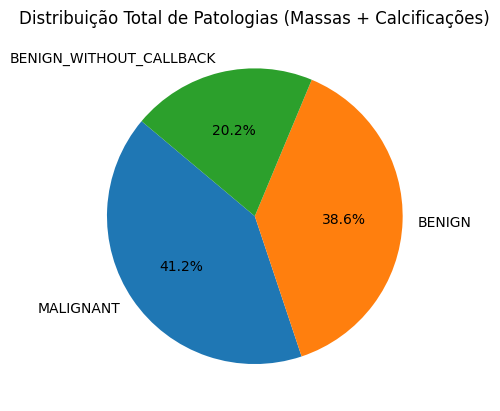

In [ ]:
#Soma as contagens de patologia de ambos os conjuntos de treino (Massas e Calcificações)
value = mass_train['pathology'].value_counts() + calc_train['pathology'].value_counts()

#Geração do Gráfico de Pizza
plt.pie(value, labels=value.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição Total de Patologias (Massas + Calcificações)', fontsize=12)
plt.savefig('distribuicao_patologias_total.png', bbox_inches='tight')

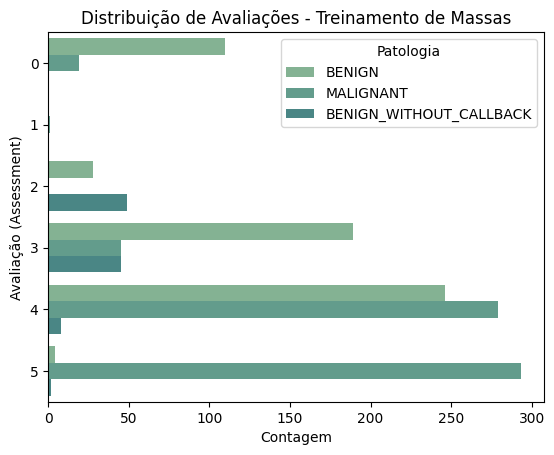

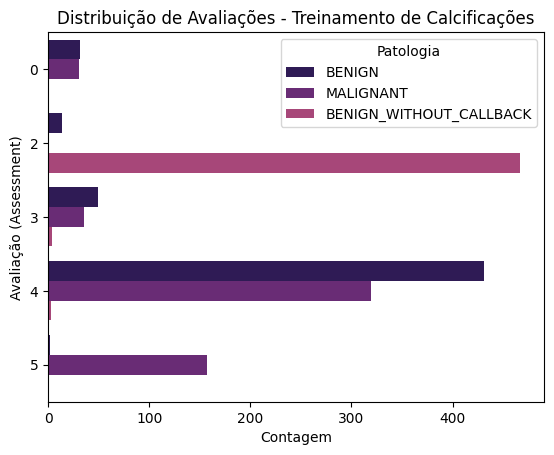

In [ ]:
# Define a paleta de cores para o conjunto de massas
mass_palette = sns.color_palette("crest", n_colors=len(mass_train['assessment'].unique()))

# Gera o gráfico de contagem cruzando Avaliação (BI-RADS) com Patologia
sns.countplot(data=mass_train, y='assessment', hue='pathology', palette=mass_palette)

# Tradução das legendas e títulos
plt.title('Distribuição de Avaliações - Treinamento de Massas')
plt.xlabel('Contagem')
plt.ylabel('Avaliação (Assessment)')
plt.legend(title='Patologia') # Traduz a legenda lateral
plt.show()

# Define a paleta de cores para o conjunto de calcificações
calc_palette = sns.color_palette("magma", n_colors=len(calc_train['assessment'].unique()))

# Gera o gráfico de contagem
sns.countplot(data=calc_train, y='assessment', hue='pathology', palette=calc_palette)

# Tradução das legendas e títulos
plt.title('Distribuição de Avaliações - Treinamento de Calcificações')
plt.xlabel('Contagem')
plt.ylabel('Avaliação (Assessment)')
plt.legend(title='Patologia')
plt.show()

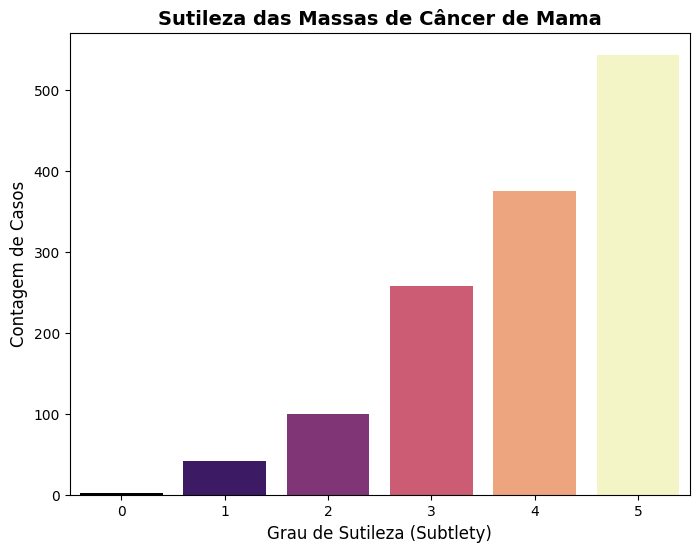

In [ ]:
#ANÁLISE DE SUTILEZA DAS MASSAS (SUBTLETY)

plt.figure(figsize=(8, 6))

# Gera o gráfico de contagem para o Grau de Sutileza
# No CBIS-DDSM, 'subtlety' indica o quão difícil é ver a lesão (1 é muito sutil, 5 é óbvia).
sns.countplot(data=mass_train, x='subtlety', palette='magma', hue='subtlety', legend=False)

# Tradução dos elementos do gráfico para o Português
plt.title('Sutileza das Massas de Câncer de Mama', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Sutileza (Subtlety)', fontsize=12)
plt.ylabel('Contagem de Casos', fontsize=12)

# Exibe o gráfico
plt.show()

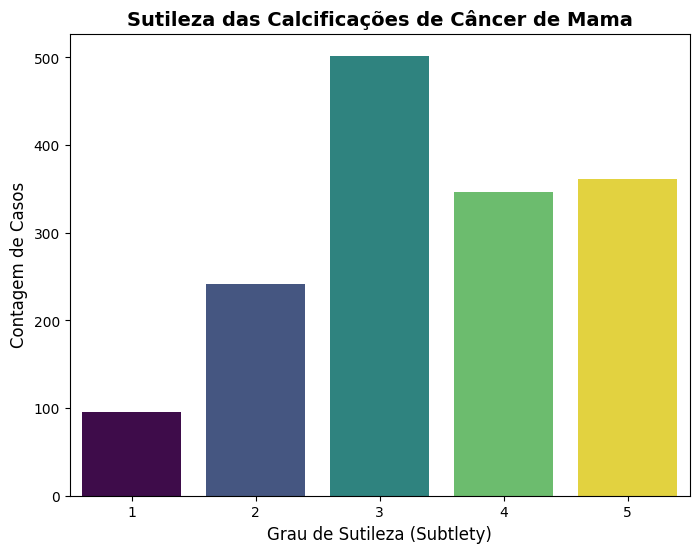

In [ ]:
# --- ANÁLISE DE SUTILEZA DAS CALCIFICAÇÕES (SUBTLETY) ---

plt.figure(figsize=(8, 6))

# Gera o gráfico de contagem para o Grau de Sutileza das Calcificações
# Usando a paleta 'viridis' conforme solicitado
sns.countplot(data=calc_train, x='subtlety', palette='viridis', hue='subtlety', legend=False)

# Tradução dos elementos do gráfico para o Português
plt.title('Sutileza das Calcificações de Câncer de Mama', fontsize=14, fontweight='bold')
plt.xlabel('Grau de Sutileza (Subtlety)', fontsize=12)
plt.ylabel('Contagem de Casos', fontsize=12)

# Exibe o gráfico final
plt.show()

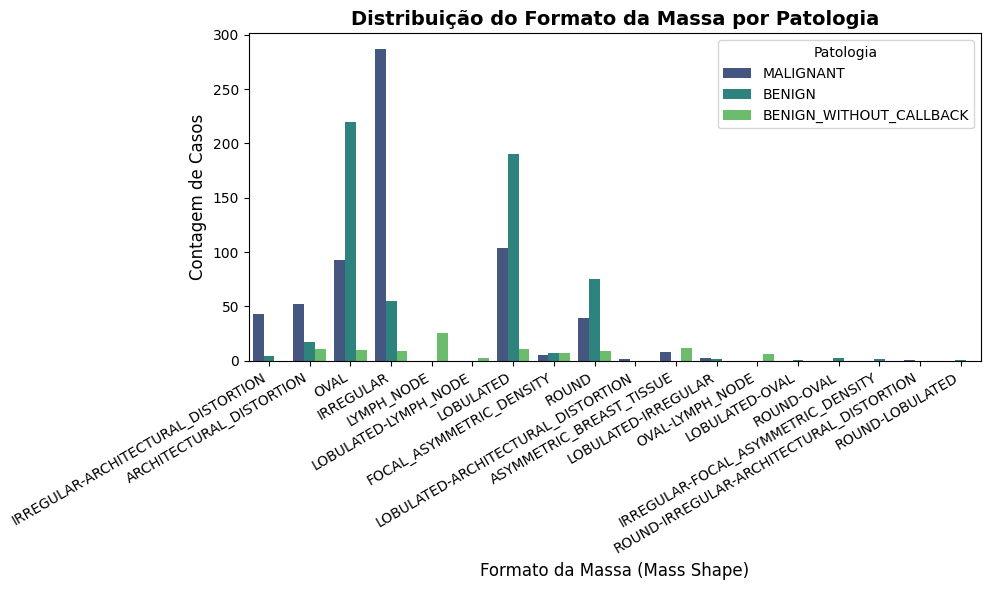

In [ ]:
# --- ANÁLISE DE FORMA DA MASSA VS. PATOLOGIA ---

plt.figure(figsize=(10, 6))

# Gera o gráfico de contagem comparando o formato da massa com o diagnóstico (Patologia)
# O parâmetro 'hue' permite ver a proporção de Malignos/Benignos para cada formato.
sns.countplot(data=mass_train, x='mass_shape', hue='pathology', palette='viridis')

# Tradução dos elementos do gráfico para o Português
plt.title('Distribuição do Formato da Massa por Patologia', fontsize=14, fontweight='bold')
plt.xlabel('Formato da Massa (Mass Shape)', fontsize=12)
plt.ylabel('Contagem de Casos', fontsize=12)

# Ajusta a rotação das legendas do eixo X para não sobrepor os nomes (ex: Irregular, Oval)
plt.xticks(rotation=30, ha='right')

# Traduz o título da legenda lateral
plt.legend(title='Patologia')

# Exibe o gráfico final
plt.tight_layout() # Garante que os rótulos não sejam cortados ao salvar
plt.show()

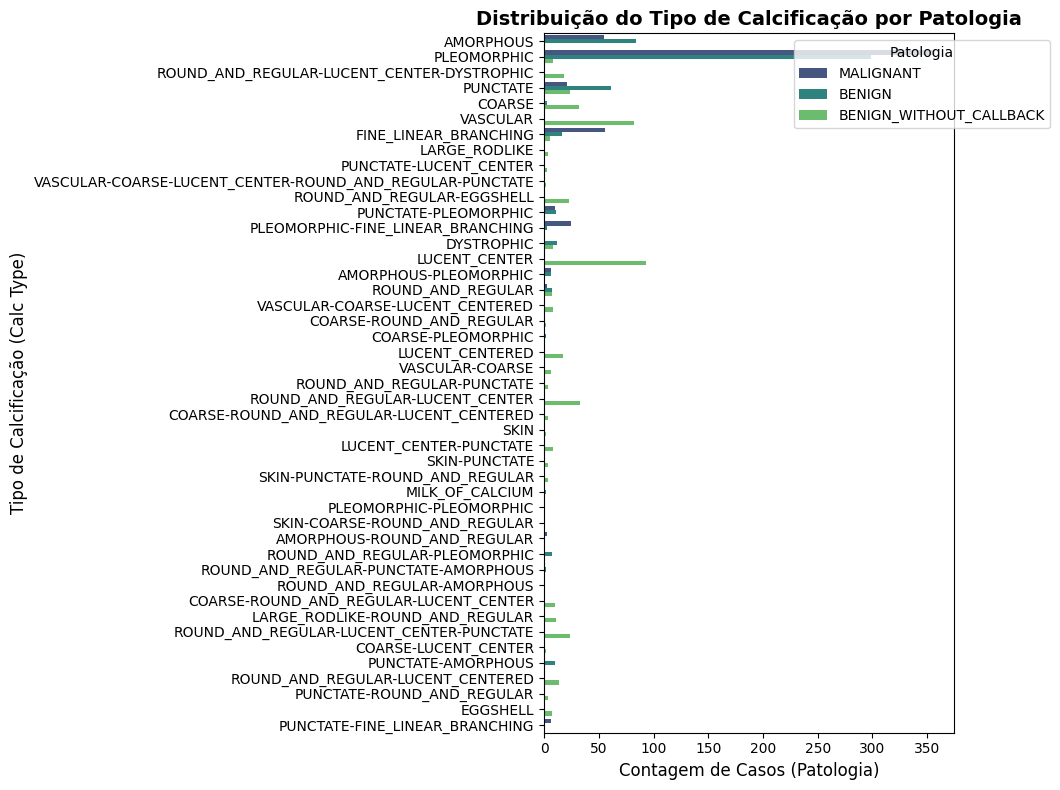

In [ ]:
# --- ANÁLISE DE TIPO DE CALCIFICAÇÃO VS. PATOLOGIA ---

plt.figure(figsize=(12, 8))

# Gera o gráfico de contagem comparando o tipo morfológico da calcificação com a Patologia
# O uso de y='calc_type' cria um gráfico horizontal, ideal para nomes longos de tipos.
sns.countplot(data=calc_train, y='calc_type', hue='pathology', palette='viridis')

# Tradução dos elementos do gráfico para o Português
plt.title('Distribuição do Tipo de Calcificação por Patologia', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Casos (Patologia)', fontsize=12)
plt.ylabel('Tipo de Calcificação (Calc Type)', fontsize=12)

# Ajuste dos rótulos do eixo Y (alinhamento à direita para leitura clara)
plt.yticks(rotation=0, ha='right')

# Move a legenda para fora do gráfico para não sobrepor as barras
plt.legend(title='Patologia', loc='upper right', bbox_to_anchor=(1.25, 1))

# Exibe o gráfico final
plt.tight_layout()
plt.show()

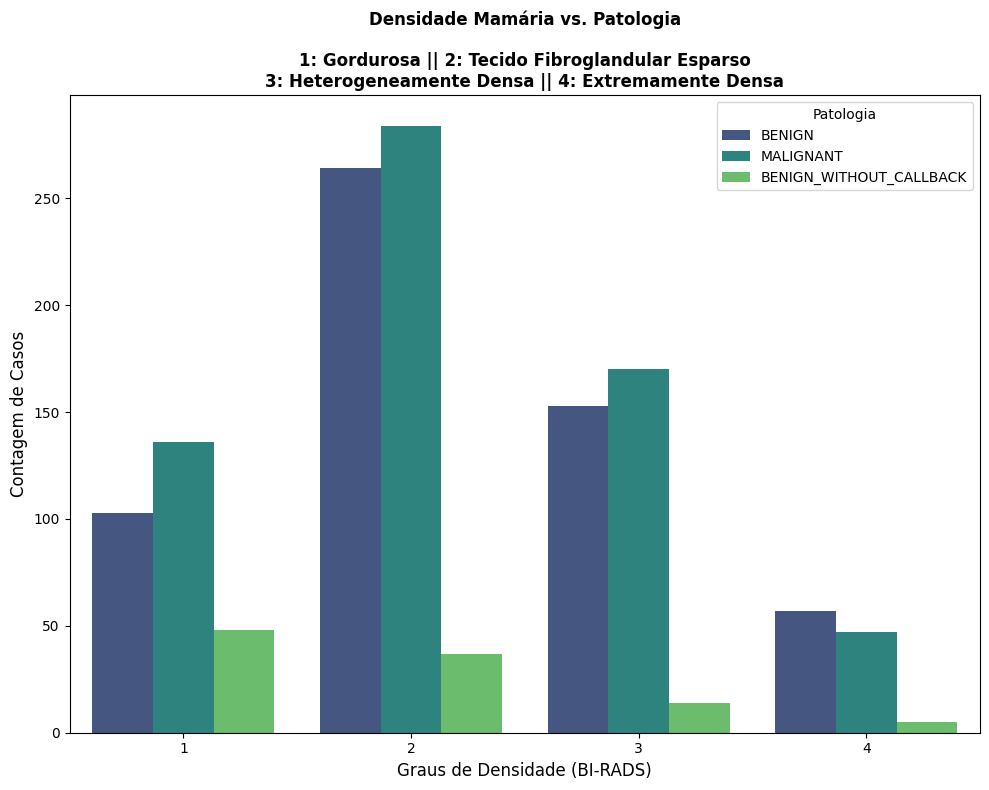

In [ ]:
# --- ANÁLISE DE DENSIDADE MAMÁRIA VS. PATOLOGIA ---

plt.figure(figsize=(10, 8))

# Gera o gráfico de contagem comparando a densidade da mama com o diagnóstico real
# 1: Gordurosa | 2: Densidades Fibroglandulares Esparsas
# 3: Heterogeneamente Densa | 4: Extremamente Densa
sns.countplot(data=mass_train, x='breast_density', hue='pathology', palette='viridis')

# Tradução dos títulos e eixos para o Português
plt.title('Densidade Mamária vs. Patologia\n\n1: Gordurosa || 2: Tecido Fibroglandular Esparso\n3: Heterogeneamente Densa || 4: Extremamente Densa',
          fontsize=12, fontweight='bold')

plt.xlabel('Graus de Densidade (BI-RADS)', fontsize=12)
plt.ylabel('Contagem de Casos', fontsize=12)

# Traduz o título da legenda lateral
plt.legend(title='Patologia')

# Ajuste fino para evitar que o título superior seja cortado
plt.tight_layout()
plt.show()

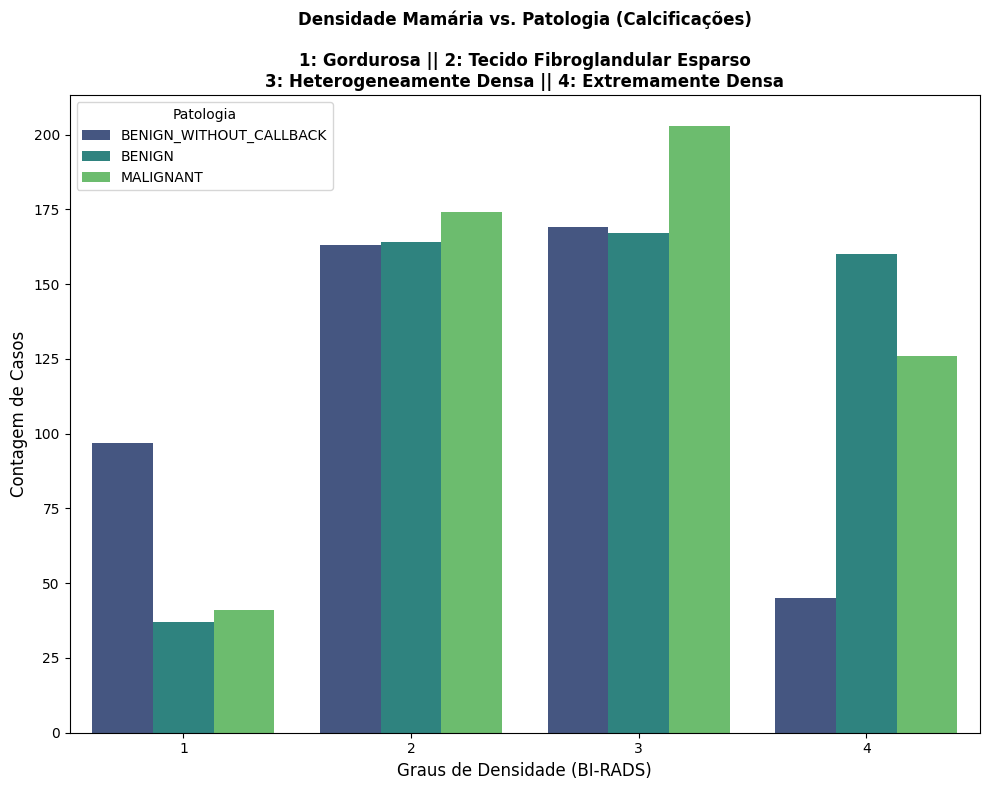

In [ ]:
# --- ANÁLISE DE DENSIDADE MAMÁRIA VS. PATOLOGIA (CALCIFICAÇÕES) ---

plt.figure(figsize=(10, 8))

# Gera o gráfico de contagem comparando a densidade da mama com o diagnóstico (Patologia)
# 1: Gordurosa | 2: Tecido Fibroglandular Esparso
# 3: Heterogeneamente Densa | 4: Extremamente Densa
sns.countplot(data=calc_train, x='breast_density', hue='pathology', palette='viridis')

# Tradução dos títulos e eixos para o Português (Padrão TCC)
plt.title('Densidade Mamária vs. Patologia (Calcificações)\n\n1: Gordurosa || 2: Tecido Fibroglandular Esparso\n3: Heterogeneamente Densa || 4: Extremamente Densa',
          fontsize=12, fontweight='bold')

plt.xlabel('Graus de Densidade (BI-RADS)', fontsize=12)
plt.ylabel('Contagem de Casos', fontsize=12)

# Tradução da legenda lateral
plt.legend(title='Patologia')

# Ajuste para garantir que o título e legendas caibam na imagem salva
plt.tight_layout()
plt.show()

In [ ]:
mass_train.head()

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,mass_shape,mass_margins,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


In [ ]:
calc_train.head()

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc_type,calc_distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...
4,P_00008,1,LEFT,CC,1,calcification,ROUND_AND_REGULAR-LUCENT_CENTER-DYSTROPHIC,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...,/content/drive/MyDrive/TCC_Cancer_Mama/dataset...


--- DATASET DE TREINAMENTO (MASSAS) ---

1. Mamografias Completas (Full Mammograms):


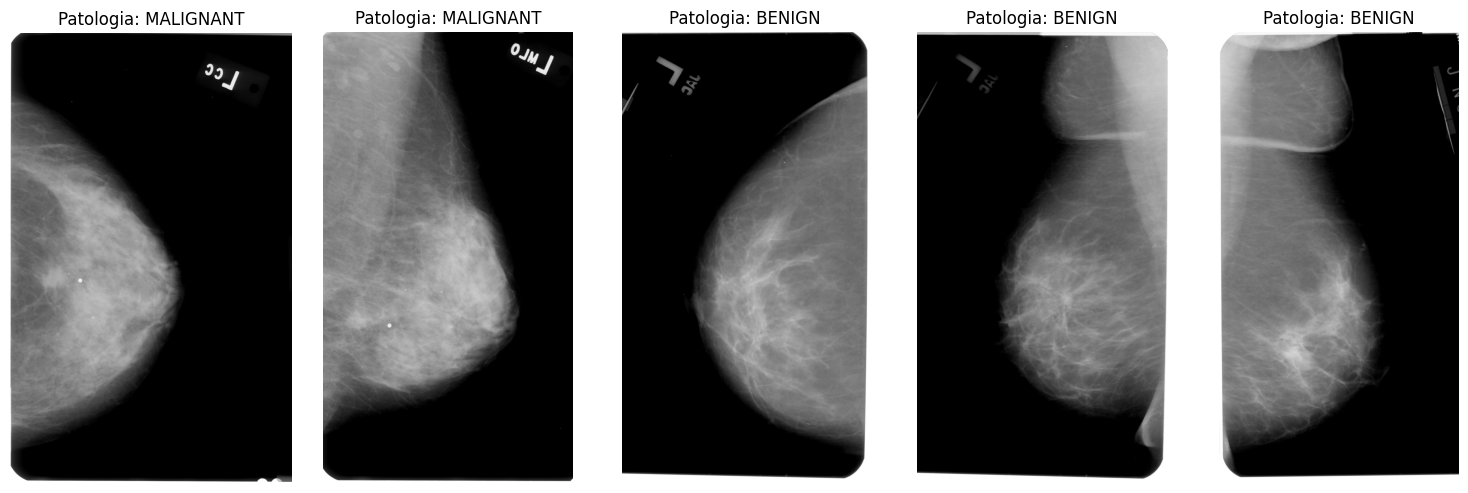


2. Recortes das Lesões (Cropped Images):


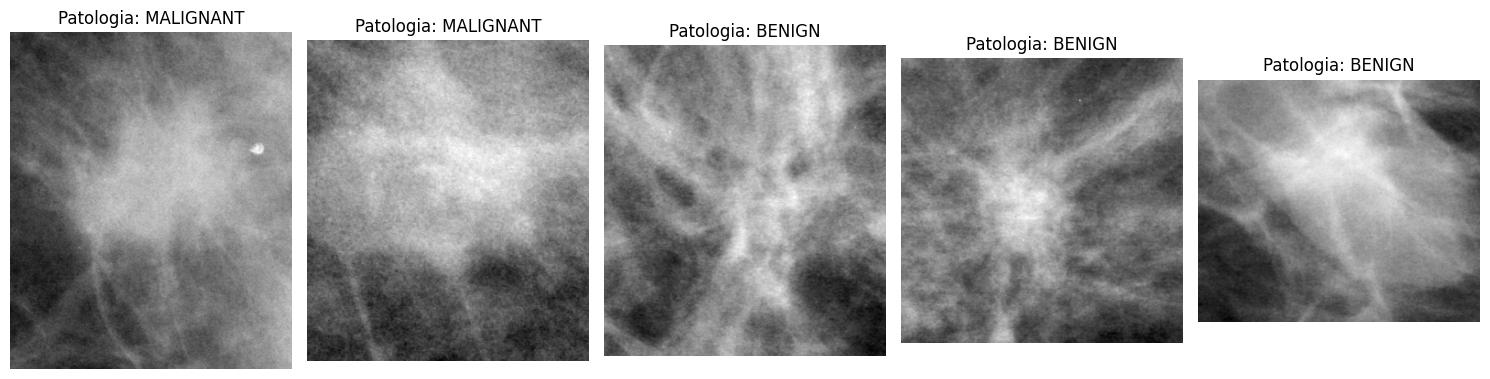


3. Máscaras da Região de Interesse (ROI Masks):


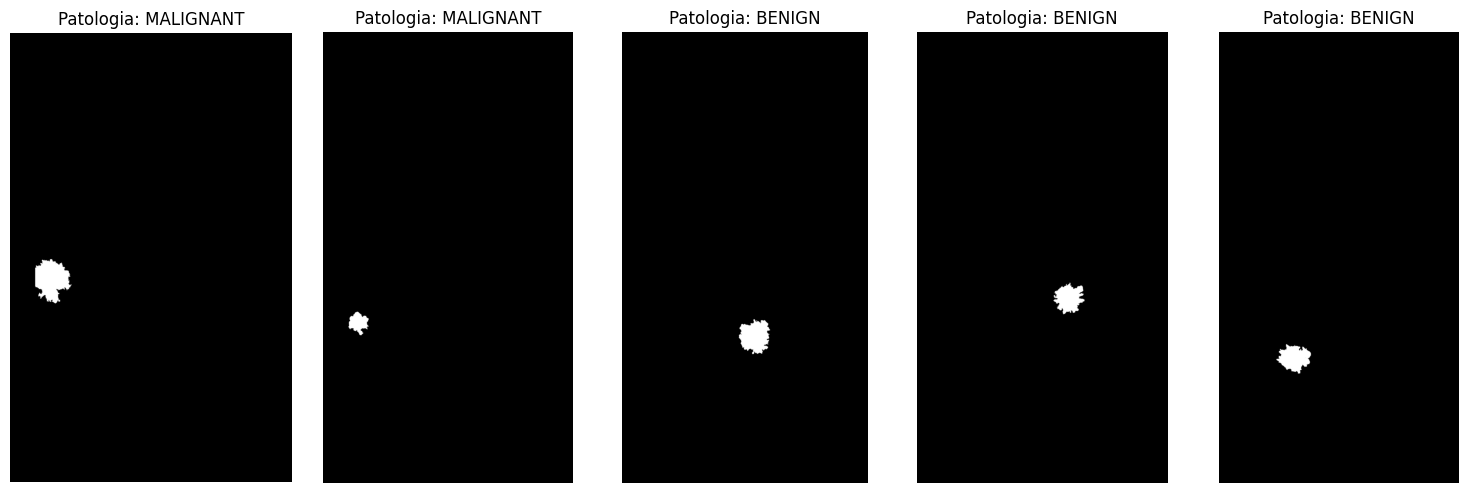

In [ ]:
import matplotlib.image as mpimg

def display_images(column, number):
    """Exibe as imagens do dataset para validação visual"""

    number_to_visualize = number
    rows = 1
    cols = number_to_visualize
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

    # Loop para percorrer as primeiras linhas e exibir as imagens
    for index, (i, row) in enumerate(mass_train.head(number_to_visualize).iterrows()):
        image_path = row[column]

        # Verifica se o arquivo físico existe no caminho mapeado
        if os.path.exists(image_path):
            image = mpimg.imread(image_path)
            ax = axes[index]
            ax.imshow(image, cmap='gray') # Exibe em escala de cinza (padrão mamográfico)

            # Título com a patologia traduzida (opcional se você já traduziu os dados)
            ax.set_title(f"Patologia: {row['pathology']}")
            ax.axis('off') # Remove os eixos para uma visualização mais limpa
        else:
            print(f"Arquivo não encontrado: {image_path}")

    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO DA VISUALIZAÇÃO ---

print('--- DATASET DE TREINAMENTO (MASSAS) ---\n')

print('1. Mamografias Completas (Full Mammograms):')
display_images('image_file_path', 5)

print('\n2. Recortes das Lesões (Cropped Images):')
# Esta é a visão que o EfficientNet geralmente usa para focar no tumor
display_images('cropped_image_file_path', 5)

print('\n3. Máscaras da Região de Interesse (ROI Masks):')
# Mostra exatamente onde o radiologista demarcou a lesão
display_images('ROI_mask_file_path', 5)

Mass Training Dataset


Full Mammograms:

/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-207.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-250.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-056.jpg


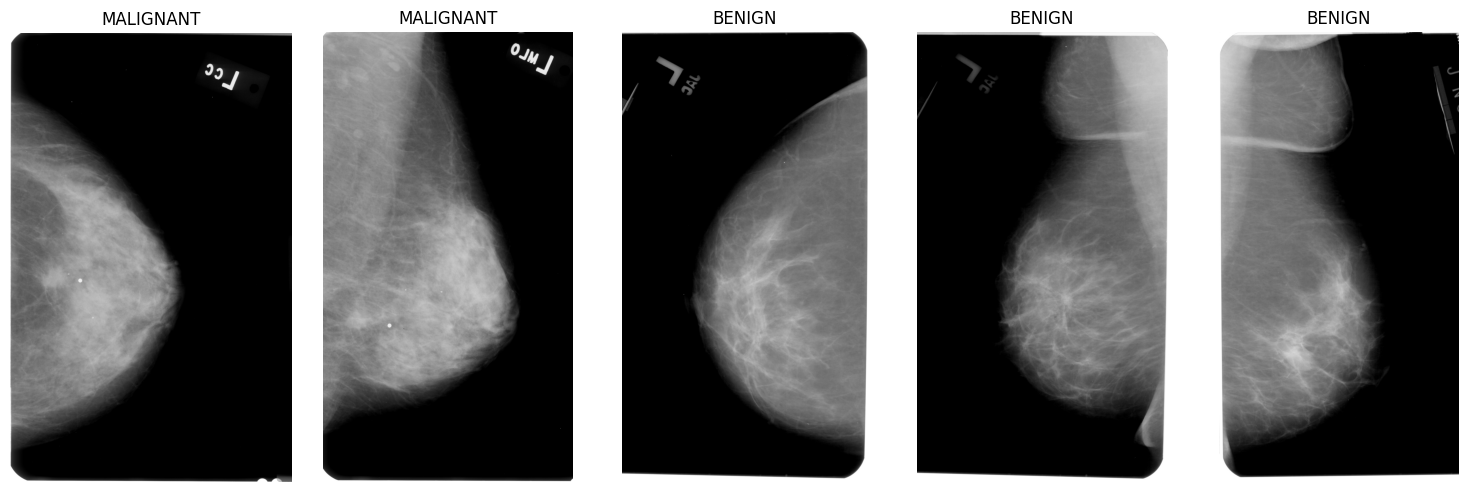

Cropped Mammograms:

/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/2-244.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/1-182.jpg


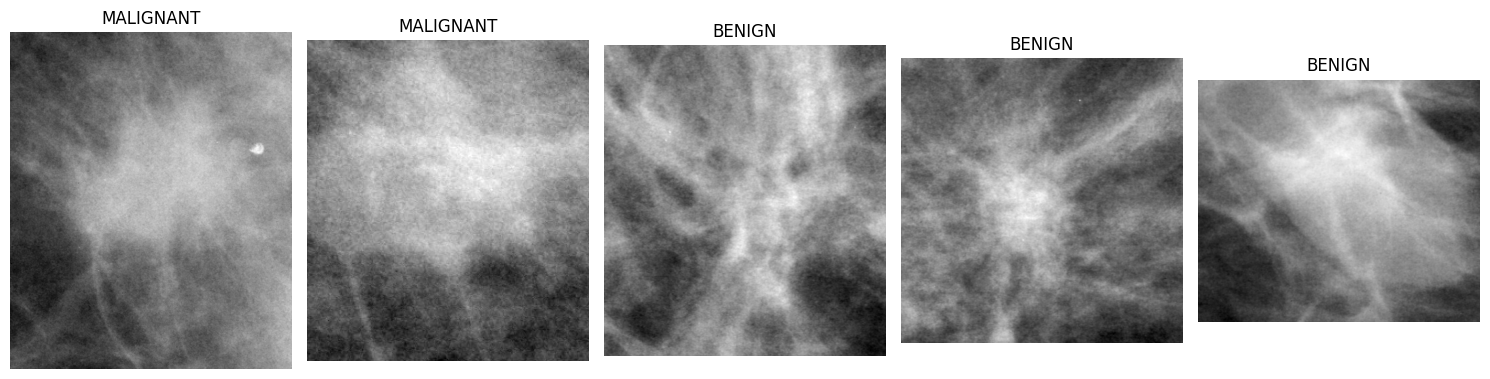

ROI Images:

/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/2-288.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/1-245.jpg
/content/drive/MyDrive/TCC_Cancer_Mama/dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/2-183.jpg


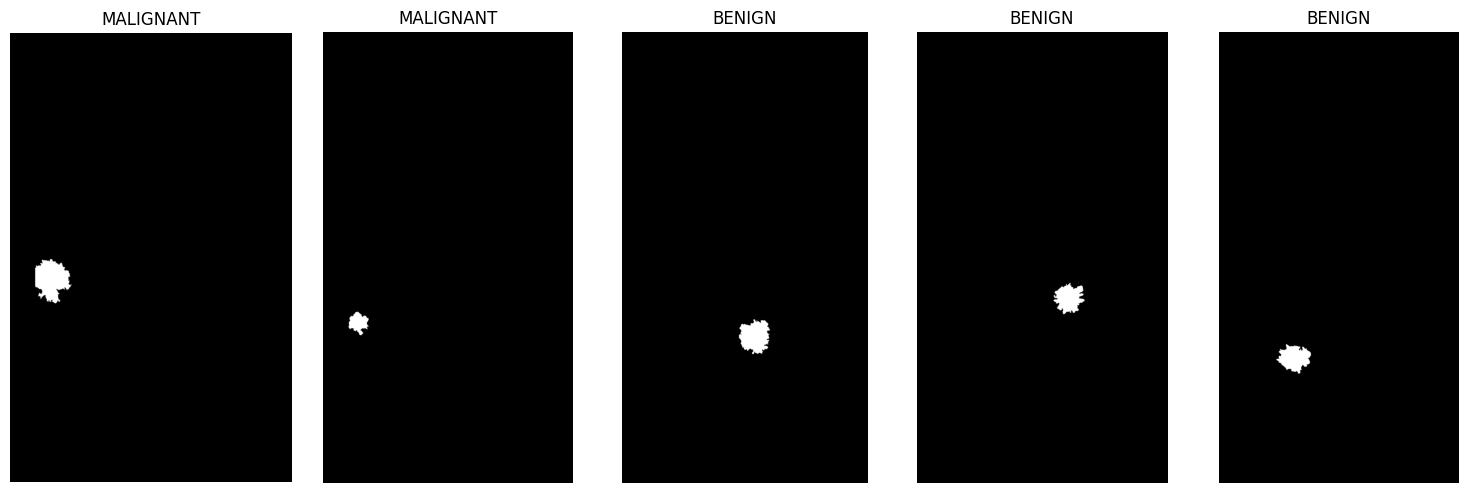

In [ ]:
import matplotlib.image as mpimg


def display_images(column, number):
    """displays images in the dataset"""
    # create figure and axes
    number_to_visualize = number
    rows = 1
    cols = number_to_visualize
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

    # Loop through rows and display images
    for index, row in mass_train.head(number_to_visualize).iterrows():
        image_path = row[column]
        print(image_path)
        # Check if the file exists
        if os.path.exists(image_path):
            image = mpimg.imread(image_path)
            ax = axes[index]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"{row['pathology']}")
            ax.axis('off')
        else:
            print(f"File not found: {image_path}")

    plt.tight_layout()
    plt.show()

print('Mass Training Dataset\n\n')
print('Full Mammograms:\n')
display_images('image_file_path', 5)
print('Cropped Mammograms:\n')
display_images('cropped_image_file_path', 5)
print('ROI Images:\n')
display_images('ROI_mask_file_path', 5)

--- DATASET DE TREINAMENTO (CALCIFICAÇÕES) ---

1. Mamografias Completas (Full Mammograms):


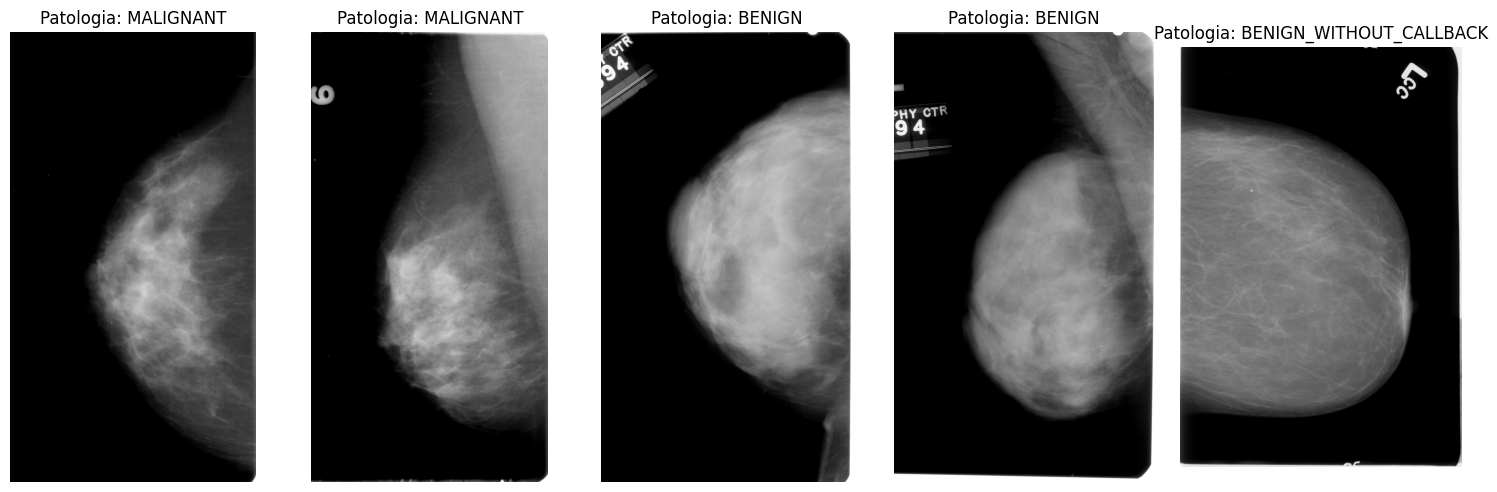


2. Recortes das Calcificações (Cropped Images):


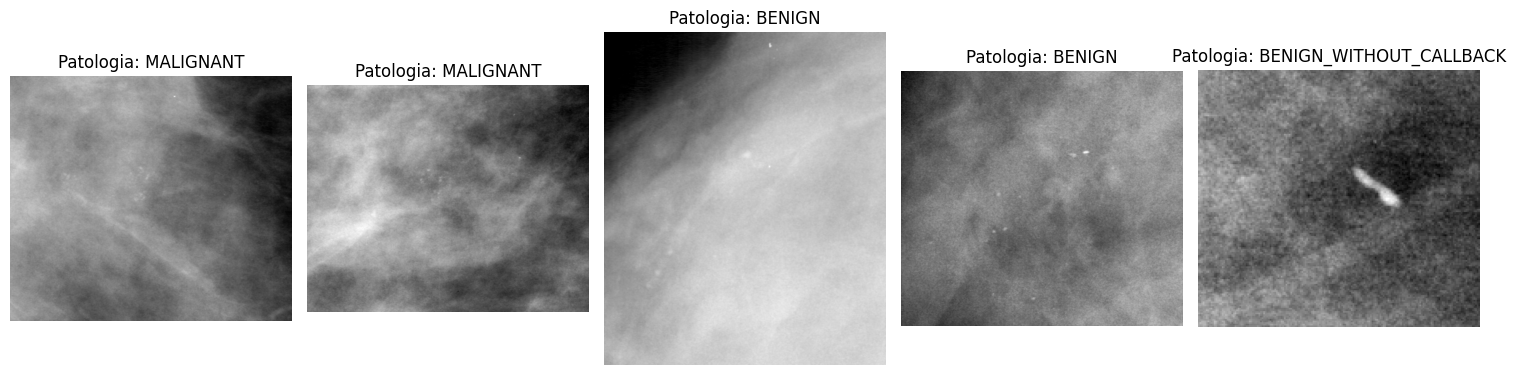


3. Máscaras de Segmentação (ROI Masks):


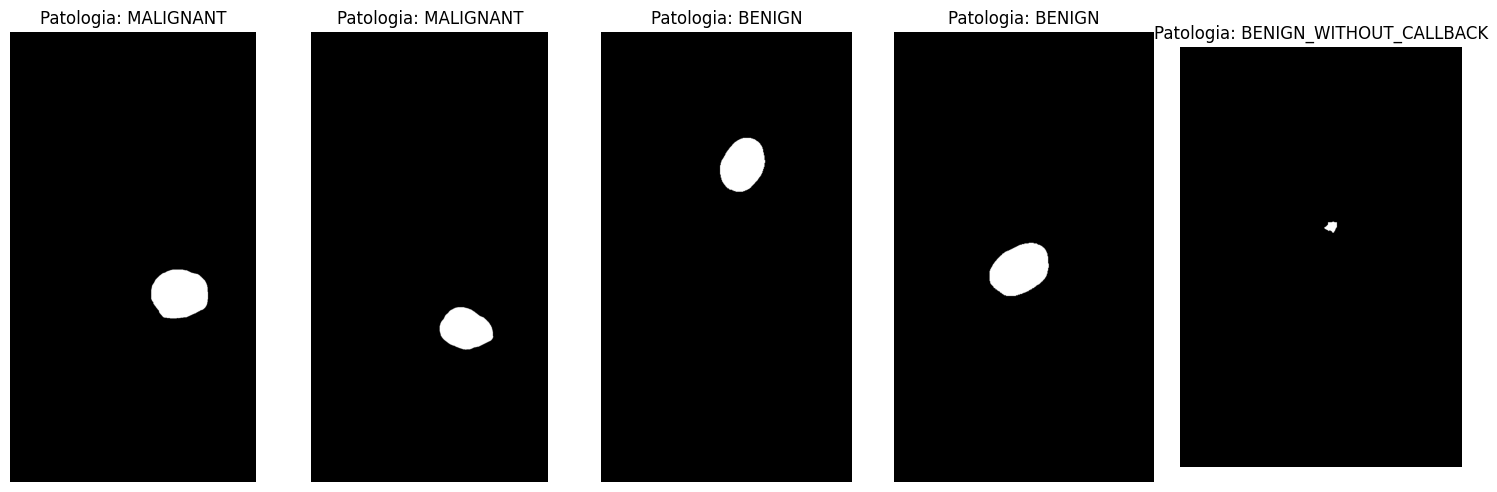

In [ ]:
# --- VISUALIZAÇÃO DO DATASET DE TREINAMENTO (CALCIFICAÇÕES) ---

def exibir_imagens_calc(coluna, quantidade):
    """Exibe uma sequência de imagens para validação visual das calcificações"""

    quantidade_visualizar = quantidade
    rows = 1
    cols = quantidade_visualizar
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

    # Itera sobre as primeiras linhas do conjunto de calcificações
    # Usamos enumerate para garantir que o índice do eixo (ax) seja sempre de 0 a quantidade-1
    for i, (index, row) in enumerate(calc_train.head(quantidade_visualizar).iterrows()):
        image_path = row[coluna]

        # Verifica se o mapeamento para o Drive funcionou (Arquivo existe?)
        if os.path.exists(image_path):
            image = mpimg.imread(image_path)
            ax = axes[i]
            ax.imshow(image, cmap='gray')

            # Título com o diagnóstico em Português
            ax.set_title(f"Patologia: {row['pathology']}")
            ax.axis('off')
        else:
            print(f"Arquivo não encontrado: {image_path}")

    plt.tight_layout()
    plt.show()

# --- EXECUÇÃO DA VISUALIZAÇÃO ---

print('--- DATASET DE TREINAMENTO (CALCIFICAÇÕES) ---\n')

print('1. Mamografias Completas (Full Mammograms):')
exibir_imagens_calc('image_file_path', 5)

print('\n2. Recortes das Calcificações (Cropped Images):')
# Essencial para ver a morfologia (pleomórfica, punctata, etc)
exibir_imagens_calc('cropped_image_file_path', 5)

print('\n3. Máscaras de Segmentação (ROI Masks):')
# Mostra a exata localização das microcalcificações
exibir_imagens_calc('ROI_mask_file_path', 5)